In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

df = pd.read_csv('../ground-truth/background-form-responses.csv')
df.columns = [
    'timestamp', 'id', 'course', 'knowledge_topics',
    'experience', 'oop_level', 'arch_level', 'github_level', 'notes'
]
df.head()

Matplotlib is building the font cache; this may take a moment.


,timestamp,id,course,knowledge_topics,experience,oop_level,arch_level,github_level,notes
0,16/04/2026 17:28:10,P1,Undergraduate Student,"Bad Smells, Refactoring, Software Architecture...",Up to 2 years of experience,medium,medium,extensive,NaN
1,16/04/2026 17:37:50,P2,Isolada,"Bad Smells, Refactoring, Software Architecture",Up to 2 years of experience,medium,medium,medium,Actually I am matlab and simulink developer.\n...
2,16/04/2026 17:30:42,P3,MSc Student,"Refactoring, Software Architecture, Web Techno...",From 3 to 5 years of experience,extensive,low,medium,NaN
3,16/04/2026 17:26:31,P4,Undergraduate Student,"Bad Smells, Refactoring, Software Architecture...",Up to 2 years of experience,extensive,medium,medium,NaN
4,16/04/2026 17:53:58,P5,Isolada,"Bad Smells, Refactoring, Software Architecture...",More than 5 years of experience,extensive,extensive,medium,"Durante minha experiencia como desenvolvedora,..."


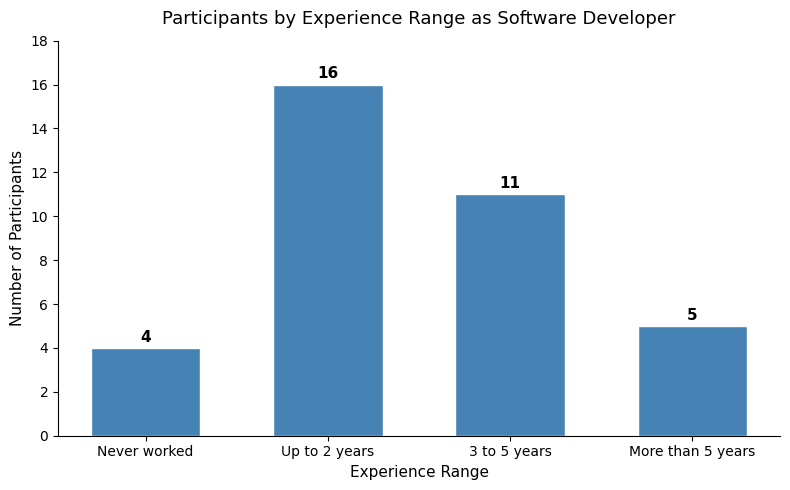

In [2]:
# --- Chart 1: Participants by experience range ---

experience_order = [
    'No, I have never worked in as a software developer',
    'Up to 2 years of experience',
    'From 3 to 5 years of experience',
    'More than 5 years of experience',
]
experience_labels = [
    'Never worked',
    'Up to 2 years',
    '3 to 5 years',
    'More than 5 years',
]

exp_counts = df['experience'].value_counts().reindex(experience_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(experience_labels, exp_counts.values, color='steelblue', edgecolor='white', width=0.6)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height + 0.15,
        str(int(height)), ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Participants by Experience Range as Software Developer', fontsize=13, pad=12)
ax.set_xlabel('Experience Range', fontsize=11)
ax.set_ylabel('Number of Participants', fontsize=11)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, exp_counts.max() + 2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('participants_by_experience.png', dpi=150)
plt.show()

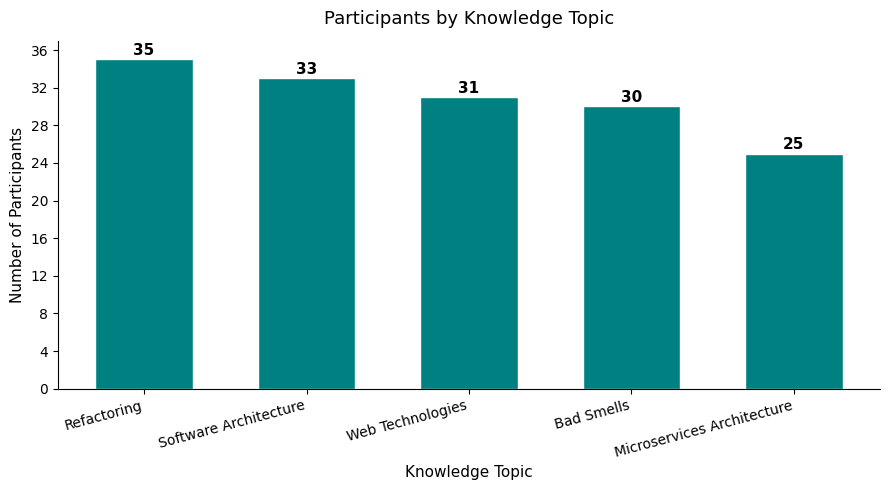

In [3]:
# --- Chart 2: Participants by knowledge topic ---

topic_counts = Counter()
for topics in df['knowledge_topics'].dropna():
    for topic in [t.strip() for t in topics.split(',')]:
        if topic:
            topic_counts[topic] += 1

topic_series = pd.Series(topic_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(topic_series.index, topic_series.values, color='teal', edgecolor='white', width=0.6)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height + 0.15,
        str(int(height)), ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Participants by Knowledge Topic', fontsize=13, pad=12)
ax.set_xlabel('Knowledge Topic', fontsize=11)
ax.set_ylabel('Number of Participants', fontsize=11)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, topic_series.max() + 2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.savefig('participants_by_knowledge.png', dpi=150)
plt.show()